In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("data/plot-data.csv")


In [3]:
ddg_df_AD = pd.read_csv("results/Binding_DDG_AD.csv",sep=",")
ddg_df_AD.loc[:, "MUT_pos"] = [int(mutation[2:-1]) for mutation in ddg_df_AD["Mutation"]]
ddg_df_AD.loc[:, "Mutation"] = [mutation[0]+str(int(mutation[2:-1]))+mutation[-1] for mutation in ddg_df_AD["Mutation"]]
ddg_df_AD = ddg_df_AD.assign(Side="B")
ddg_df_DA = pd.read_csv("results/Binding_DDG_DA.csv",sep=",")
ddg_df_DA.loc[:, "MUT_pos"] = [int(mutation[2:-1]) for mutation in ddg_df_DA["Mutation"]]
ddg_df_DA.loc[:, "Mutation"] = [mutation[0]+str(int(mutation[2:-1]))+mutation[-1] for mutation in ddg_df_DA["Mutation"]]
ddg_df_DA = ddg_df_DA.assign(Side="A")
ddg_df = pd.concat([ddg_df_AD,ddg_df_DA])
ddg_df = ddg_df.iloc[:, [0,5, 4, 1, 2,3]].sort_values('MUT_pos')

In [4]:
for index, row in df.iterrows():
    mutation, side = row["Mutation"], row["Side"]

    processed_mut = mutation.strip("*")
    transformed_mut = (
        processed_mut[0]
        + str(int(processed_mut[1:-1]) + 87)
        + processed_mut[-1]
    )

    match = ddg_df.loc[
        (ddg_df["Mutation"] == transformed_mut) &
        (ddg_df["Side"] == side),
        "DDG"
    ]

    if not match.empty:
        df.loc[index, "DDG"] = match.iloc[0]
    else:
        df.loc[index, "DDG"] = np.nan


In [5]:
mut = df["Mutation"]
potential = df["x"]
y_pos = np.arange(len(potential))/1.1
ddg = df["DDG"]

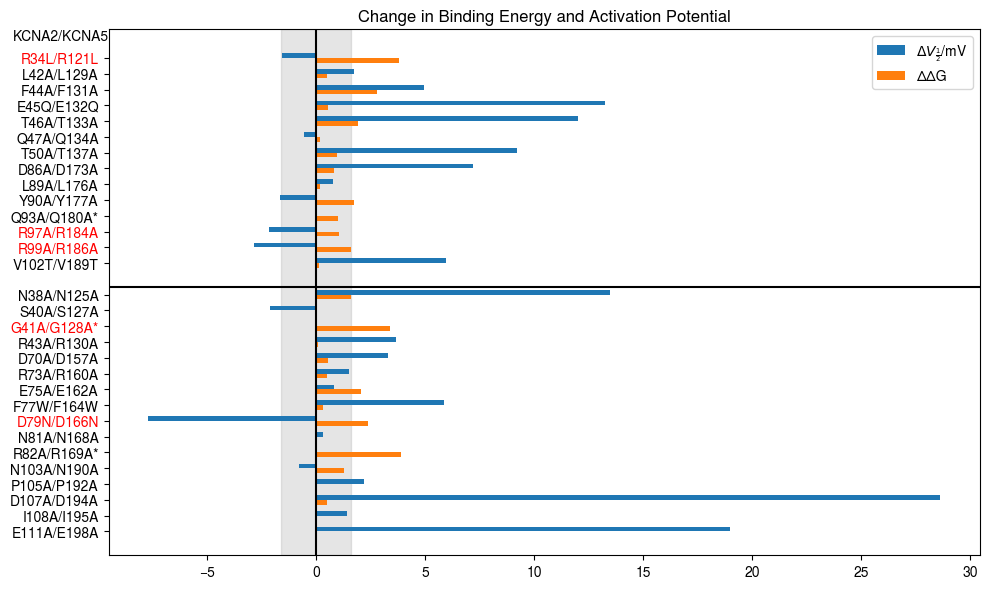

In [6]:
# Increase spacing between mutation groups
y = np.concatenate([np.arange(14) * 4, 60 + np.arange(16) * 4])

bar_height = 1.2
offset = bar_height / 2  # bars touch exactly

fig, ax = plt.subplots(figsize=(10, 6))

# shaded neutral zone
ax.axvspan(-1.608, 1.608, color='gray', alpha=0.2, zorder=0)

# grouped bars (touching)
ax.barh(y - offset, potential, height=bar_height,
        label=r"$\Delta V_{{\frac{{1}}{{2}}}}$/mV", zorder=2)

ax.barh(y + offset, ddg, height=bar_height,
        label="ΔΔG", zorder=2)

ax.set_yticks(y)

# Build dual labels: KCNA2_mut/KCNA5_mut (KCNA5 residue = KCNA2 + 87)
def dual_label(m):
    raw = m.strip("*")
    aa_from, pos, aa_to = raw[0], int(raw[1:-1]), raw[-1]
    kcna5_label = aa_from + str(pos + 87) + aa_to
    suffix = "*" if m.endswith("*") else ""
    return f"{raw}/{kcna5_label}{suffix}"

dual_labels = [dual_label(m) for m in mut]
ax.set_yticklabels(dual_labels)

# highlight labels — match on original KCNA2 mutation
red_labels = {"R34L", "R97A", "R99A", "G41A*", "D79N"}
for label, orig in zip(ax.get_yticklabels(), mut):
    if orig in red_labels:
        label.set_color("red")

ax.axvline(0, color="black", linewidth=1.5)
ax.axhline(58, color="black", linewidth=1.5)

# Add note explaining dual label format
ax.annotate("KCNA2/KCNA5",
            xy=(0, 1.0), xycoords=("axes fraction", "axes fraction"),
            fontsize=10, color="black", ha="right", va="top")
ax.invert_yaxis()
ax.legend()
plt.title("Change in Binding Energy and Activation Potential")
plt.tight_layout()
plt.show()
